<a href="https://colab.research.google.com/github/Kh0uloud/Modeling-Mental-Health-Trends-Using-Social-Media-Data/blob/main/Depression_Prediction_From_Language_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
import json
from glob import glob
import os
from tqdm import tqdm
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
import re
from pathlib import Path
from dateutil import parser
import ast

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import scipy.stats as stats
import math

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.model_selection import train_test_split
import shap

from statsmodels.api import OLS

tqdm.pandas()

# Unzipping Data

In [ ]:
!apt-get install p7zip-full -y  # Install 7-Zip (only needed once)
!7z x "/content/drive/MyDrive/MentalHealthProject/Dataset_MDDL.zip" -o"/content/data" -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 29 not upgraded.

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs AMD EPYC 7B12 (830F10),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/drive/MyDrive/MentalHealthProject/                                                     1 file, 8393734330 bytes (8005 MiB)

Extracting archive: /content/drive/MyDrive/MentalHealthProject/Dataset_MDDL.zip
  2% 4096 Open               10% 20480 Open                43% 81920 Open                79% 151552 Open                

In [ ]:
shutil.move("/content/data/Dataset/labeled/positive", "/content/drive/MyDrive/MentalHealthProject/LabeledPos")

'/content/drive/MyDrive/MentalHealthProject/LabeledPos'

In [ ]:
shutil.copytree("/content/data/Dataset/labeled/negative", "/content/drive/MyDrive/MentalHealthProject/LabeledNeg")

'/content/drive/MyDrive/MentalHealthProject/LabeledNeg'

In [ ]:
shutil.rmtree("/content/data")

# Data

The dataset is the MDDL (Multimodal Dictionary Learning) dataset, designed for depression detection via social media, specifically Twitter. It contains a combination of user profile features, tweet metadata, and timelines of user interactions. This dataset has been used to create two distinct labels: depressed and non-depressed users based on the content of their tweets. <br>

<h4>Structure of the Dataset: </h4>

1.   Users: Each JSON file in this folder contains detailed information about a specific user. Each record includes user profile features (account metadata, profile details, activity statistics, etc.)
2.   Tweets: Each JSON file in this folder contains tweet-level data with information such as the tweet content, sentiment, engagement statistics (like retweets and likes), and metadata.
3.	Timeline: This folder contains multiple rows per file, each representing a tweet from a particular user. These rows contain time-stamped data such as tweet content, engagement, and user interaction metadata.


## Data Extraction

In [ ]:
pos_data = "/content/drive/MyDrive/MentalHealthProject/LabeledPos/data"
files = glob(os.path.join(pos_data, "timeline", "*.json"))

# Read all JSON files and concatenate them
df_timeline_list = [pd.read_json(file, lines=True) for file in tqdm(files)]
df_timeline_pos = pd.concat(df_timeline_list, ignore_index=True)

100%|██████████| 2622/2622 [07:43<00:00,  5.66it/s]


In [ ]:
neg_data = "/content/drive/MyDrive/MentalHealthProject/LabeledNeg/data"

files = glob(os.path.join(neg_data, "timeline", "*.json"))

non_empty_files = []  # List to store non-empty file names
def process_json_file(file_path):
    """Reads a JSON file, extracts valid JSON objects, and returns a DataFrame."""
    with open(file_path, "r", encoding="utf-8") as file:
        content = file.read().strip()

    # Split based on `{"created_at"`, keeping the delimiter
    objects = re.split(r'(?=\{"created_at")', content)

    json_objects = []
    for obj in objects:
        obj = obj.strip()
        if obj:
            try:
                json_objects.append(json.loads(obj))
            except json.JSONDecodeError:
                continue  # Skip invalid JSON objects

    if json_objects:
        non_empty_files.append(file_path)  # Store non-empty file names

    return pd.DataFrame(json_objects) if json_objects else pd.DataFrame()

def process_multiple_json_files(file_paths):
    """Processes multiple JSON files and concatenates the resulting DataFrames."""
    dfs = [process_json_file(file) for file in tqdm(file_paths)]
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

# Process all files
df_timeline_neg = process_multiple_json_files(files)

## Data Preprocessing and Cleaning

#### Timeline Positive Data (Target/Depression = True)

In [ ]:
df_timeline_pos["user_id"] = df_timeline_pos["user"].progress_apply(lambda x: x.get("id") if isinstance(x, dict) else None)
print(f"\n{df_timeline_pos.user_id.nunique()}")

100%|██████████| 506158/506158 [00:01<00:00, 408878.25it/s]


2512


In [ ]:
df_timeline_pos.columns

Index(['created_at', 'id', 'id_str', 'text', 'truncated', 'entities', 'source',
       'in_reply_to_status_id', 'in_reply_to_status_id_str',
       'in_reply_to_user_id', 'in_reply_to_user_id_str',
       'in_reply_to_screen_name', 'user', 'geo', 'coordinates', 'place',
       'contributors', 'is_quote_status', 'retweet_count', 'favorite_count',
       'favorited', 'retweeted', 'possibly_sensitive', 'lang',
       'extended_entities', 'retweeted_status', 'quoted_status_id',
       'quoted_status_id_str', 'quoted_status', 'withheld_scope',
       'withheld_copyright', 'withheld_in_countries', 'user_id'],
      dtype='object')

In [ ]:
df_timeline_pos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506158 entries, 0 to 506157
Data columns (total 33 columns):
 #   Column                     Non-Null Count   Dtype              
---  ------                     --------------   -----              
 0   created_at                 506158 non-null  datetime64[ns, UTC]
 1   id                         506158 non-null  int64              
 2   id_str                     506158 non-null  int64              
 3   text                       506158 non-null  object             
 4   truncated                  506158 non-null  bool               
 5   entities                   506158 non-null  object             
 6   source                     506158 non-null  object             
 7   in_reply_to_status_id      117609 non-null  float64            
 8   in_reply_to_status_id_str  117609 non-null  float64            
 9   in_reply_to_user_id        135908 non-null  float64            
 10  in_reply_to_user_id_str    135908 non-null  float64     

In [ ]:
# Number of duplicate rows
red_rows_all_data = df_timeline_pos.duplicated(['created_at', 'id', 'id_str', 'text', 'truncated', 'source',
                                                'in_reply_to_status_id', 'in_reply_to_status_id_str',
                                                'in_reply_to_user_id', 'in_reply_to_user_id_str',
                                                'in_reply_to_screen_name', 'contributors', 'is_quote_status',
                                                'retweet_count', 'favorite_count', 'favorited', 'retweeted',
                                                'possibly_sensitive', 'lang', 'quoted_status_id', 'quoted_status_id_str',
                                                'withheld_scope', 'withheld_copyright', 'user_id']).sum()
print(f"Number of redundant rows: {red_rows_all_data}")

red_rows = df_timeline_pos.duplicated(subset=['user_id', 'text']).sum()
print(f"Number of redundant rows (on user_id and tweet): {red_rows}")

df_timeline_pos = df_timeline_pos.drop_duplicates(subset=["user_id", "text"])

Number of redundant rows: 15442
Number of redundant rows (on user_id and tweet): 18099


In [ ]:
df_timeline_pos

,created_at,id,id_str,text,truncated,entities,source,in_reply_to_status_id,in_reply_to_status_id_str,in_reply_to_user_id,...,lang,extended_entities,retweeted_status,quoted_status_id,quoted_status_id_str,quoted_status,withheld_scope,withheld_copyright,withheld_in_countries,user_id
0,2015-01-14 01:05:16+00:00,555168736664363009,555168736664363008,Lady Sings the Blues - 'I was diagnosed with c...,False,"{'hashtags': [{'text': 'mentalhealth', 'indice...","<a href=""http://www.hootsuite.com"" rel=""nofoll...",NaN,NaN,NaN,...,en,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88746594
1,2015-01-13 19:05:24+00:00,555078174368088064,555078174368088064,Looking for a book that helps explain mental h...,False,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://www.hootsuite.com"" rel=""nofoll...",NaN,NaN,NaN,...,en,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88746594
2,2015-01-13 13:40:21+00:00,554996372123156480,554996372123156480,What is #mentalillness ? http://t.co/JXz6622Rfy,False,"{'hashtags': [{'text': 'mentalillness', 'indic...","<a href=""http://www.hootsuite.com"" rel=""nofoll...",NaN,NaN,NaN,...,en,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88746594
3,2015-01-13 01:05:15+00:00,554806345573339136,554806345573339136,Check out our online bookstore to read up on #...,False,"{'hashtags': [{'text': 'mentalhealth', 'indice...","<a href=""http://www.hootsuite.com"" rel=""nofoll...",NaN,NaN,NaN,...,en,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88746594
4,2015-01-13 00:50:16+00:00,554802576374628352,554802576374628352,Does Legalizing #Marijuana Also Lower Overdose...,False,"{'hashtags': [{'text': 'Marijuana', 'indices':...","<a href=""http://www.hootsuite.com"" rel=""nofoll...",NaN,NaN,NaN,...,en,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88746594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
506146,2015-12-31 08:01:46+00:00,682471696234840064,682471696234840064,"@ItsJRE I've been with EXO for a long time, an...",False,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://twitter.com/download/iphone"" r...",6.818503e+17,6.818503e+17,432587869.0,...,en,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,583084366
506147,2015-12-31 08:01:06+00:00,682471528928292864,682471528928292864,"@ItsJRE He may be my bias, but it's not just b...",False,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://twitter.com/download/iphone"" r...",6.818503e+17,6.818503e+17,432587869.0,...,en,"{'media': [{'id': 682471485076848641, 'id_str'...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,583084366
506148,2015-12-31 08:00:00+00:00,682471249013043201,682471249013043200,@ItsJRE He pushes himself so hard and strives ...,False,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://twitter.com/download/iphone"" r...",6.818503e+17,6.818503e+17,432587869.0,...,en,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,583084366
506149,2015-12-31 07:58:17+00:00,682470819893739520,682470819893739520,@ItsJRE Kai's dedication inspired me to get ba...,False,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://twitter.com/download/iphone"" r...",6.818503e+17,6.818503e+17,432587869.0,...,en,"{'media': [{'id': 682470791800320000, 'id_str'...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,583084366


In [ ]:
df_timeline_pos = df_timeline_pos[df_timeline_pos['lang']=='en']

In [ ]:
df_timeline_pos.truncated.nunique(), df_timeline_pos.source.nunique(), df_timeline_pos.contributors.nunique(), df_timeline_pos.possibly_sensitive.nunique(), df_timeline_pos.lang.nunique(), df_timeline_pos.withheld_scope.nunique(), df_timeline_pos.withheld_copyright.nunique()

(1, 263, 0, 2, 1, 1, 1)

In [ ]:
df_timeline_pos.drop(['contributors', 'lang', 'withheld_scope', 'user',
                      'withheld_copyright', 'withheld_in_countries'], axis=1, inplace=True)

<ipython-input-81-936334cb45e6>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_timeline_pos.drop(['contributors', 'lang', 'withheld_scope', 'user',


#### Timeline Negative Data (Target/Depression = False)

In [ ]:
df_timeline_neg["user"] = df_timeline_neg["user"].progress_apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df_timeline_neg["user_id"] = df_timeline_neg["user"].progress_apply(lambda x: x.get("id") if isinstance(x, dict) else None)
print(df_timeline_neg["user_id"].nunique())

<ipython-input-3-ed3f5068f101>:2: DtypeWarning: Columns (13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df_timeline_neg1 = pd.read_csv(save_path1)
<ipython-input-3-ed3f5068f101>:5: DtypeWarning: Columns (13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df_timeline_neg2 = pd.read_csv(save_path2)
<ipython-input-3-ed3f5068f101>:8: DtypeWarning: Columns (27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df_timeline_neg3 = pd.read_csv(save_path3)
100%|██████████| 2711606/2711606 [00:03<00:00, 727344.70it/s]

3966


In [ ]:
df_timeline_neg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2711606 entries, 0 to 2711605
Data columns (total 31 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   created_at                 object 
 1   id                         int64  
 2   id_str                     int64  
 3   text                       object 
 4   truncated                  bool   
 5   entities                   object 
 6   source                     object 
 7   in_reply_to_status_id      float64
 8   in_reply_to_status_id_str  float64
 9   in_reply_to_user_id        float64
 10  in_reply_to_user_id_str    float64
 11  in_reply_to_screen_name    object 
 12  user                       object 
 13  geo                        object 
 14  coordinates                object 
 15  place                      object 
 16  contributors               float64
 17  is_quote_status            bool   
 18  retweet_count              int64  
 19  favorite_count             int64  
 20  fa

In [ ]:
# Number of duplicate rows
red_rows_all_data = df_timeline_neg.duplicated(['created_at', 'id', 'id_str', 'text', 'truncated', 'entities',
                                       'source', 'in_reply_to_status_id', 'in_reply_to_status_id_str',
                                       'in_reply_to_user_id', 'in_reply_to_user_id_str',
                                       'in_reply_to_screen_name', 'geo', 'coordinates', 'place',
                                       'contributors', 'is_quote_status', 'retweet_count', 'favorite_count',
                                       'favorited', 'retweeted', 'possibly_sensitive', 'lang',
                                       'extended_entities', 'quoted_status_id', 'quoted_status_id_str',
                                       'withheld_scope', 'withheld_copyright', 'withheld_in_countries',
                                       'user_id']).sum()
print(f"Number of redundant rows: {red_rows_all_data}")

red_rows = df_timeline_neg.duplicated(subset=["user_id", "text"]).sum()
print(f"Number of redundant rows (on user_id and tweet): {red_rows}")

df_timeline_neg = df_timeline_neg.drop_duplicates(subset=["user_id", "text"])

Number of redundant rows: 763312
Number of redundant rows (on user_id and tweet): 1023645


In [ ]:
df_timeline_neg = df_timeline_neg[df_timeline_neg['lang']=='en']

In [ ]:
df_timeline_neg.columns

Index(['created_at', 'id', 'id_str', 'text', 'truncated', 'entities', 'source',
       'in_reply_to_status_id', 'in_reply_to_status_id_str',
       'in_reply_to_user_id', 'in_reply_to_user_id_str',
       'in_reply_to_screen_name', 'user', 'geo', 'coordinates', 'place',
       'contributors', 'is_quote_status', 'retweet_count', 'favorite_count',
       'favorited', 'retweeted', 'possibly_sensitive', 'lang',
       'extended_entities', 'quoted_status_id', 'quoted_status_id_str',
       'withheld_scope', 'withheld_copyright', 'withheld_in_countries',
       'user_id'],
      dtype='object')

In [ ]:
df_timeline_neg.truncated.nunique(), df_timeline_neg.entities.nunique(), df_timeline_neg.source.nunique(), df_timeline_neg.geo.nunique(), df_timeline_neg.place.nunique(), df_timeline_neg.contributors.nunique(), df_timeline_neg.possibly_sensitive.nunique(), df_timeline_neg.lang.nunique(), df_timeline_neg.withheld_scope.nunique(), df_timeline_neg.withheld_copyright.nunique(), df_timeline_neg.withheld_in_countries.nunique(),

(2, 399406, 319, 915, 1250, 0, 2, 1, 1, 1, 1)

In [ ]:
df_timeline_neg.drop(['contributors', 'lang', 'withheld_scope', 'user',
                      'withheld_copyright', 'withheld_in_countries'], axis=1, inplace=True)

In [ ]:
df_timeline_neg

,created_at,id,id_str,text,truncated,entities,source,in_reply_to_status_id,in_reply_to_status_id_str,in_reply_to_user_id,...,is_quote_status,retweet_count,favorite_count,favorited,retweeted,possibly_sensitive,extended_entities,quoted_status_id,quoted_status_id_str,user_id
0,Mon Jan 09 05:21:13 +0000 2017,818326742515544065,818326742515544065,RT alshlaqy: Techecho_Ar \nFile manager,False,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://ifttt.com"" rel=""nofollow"">IFTT...",NaN,NaN,NaN,...,False,0,0,False,False,NaN,NaN,NaN,NaN,2451860677
1,Fri Jan 06 18:53:39 +0000 2017,817444033991741440,817444033991741440,RT HmoodePhone: Techecho_Ar twitter,False,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://ifttt.com"" rel=""nofollow"">IFTT...",NaN,NaN,NaN,...,False,0,0,False,False,NaN,NaN,NaN,NaN,2451860677
2,Fri Jan 06 18:18:07 +0000 2017,817435090989023232,817435090989023232,RT GhoshehTareq: Techecho_Ar google fit,False,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://ifttt.com"" rel=""nofollow"">IFTT...",NaN,NaN,NaN,...,False,0,0,False,False,NaN,NaN,NaN,NaN,2451860677
3,Wed Jan 11 16:57:31 +0000 2017,819226748344737794,819226748344737794,baby https://t.co/Xwh4Psk7CF,False,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://twitter.com/download/android"" ...",NaN,NaN,NaN,...,False,1,2,False,False,False,"{'media': [{'id': 819226277462863873, 'id_str'...",NaN,NaN,390569110
4,Sun Jan 08 21:37:28 +0000 2017,818210034857496576,818210034857496576,[MV] AFTER SCHOOL '첫사랑(First Love)' Music Vid...,False,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://twitter.com"" rel=""nofollow"">Tw...",NaN,NaN,NaN,...,False,0,0,False,False,False,NaN,NaN,NaN,390569110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1089910,Wed Dec 14 11:19:26 +0000 2016,808994806722600960,808994806722600960,I liked a @YouTube video from @chaboyyhd https...,False,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://www.google.com/"" rel=""nofollow...",NaN,NaN,NaN,...,False,0,0,False,False,False,NaN,NaN,NaN,390684514
1089911,Wed Dec 14 10:58:37 +0000 2016,808989567722422272,808989567722422272,I liked a @YouTube video from @taraartsgame ht...,False,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://www.google.com/"" rel=""nofollow...",NaN,NaN,NaN,...,False,0,0,False,False,False,NaN,NaN,NaN,390684514
1089912,Wed Dec 14 09:12:53 +0000 2016,808962955740151808,808962955740151808,I liked a @YouTube video from @taraartsgame ht...,False,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://www.google.com/"" rel=""nofollow...",NaN,NaN,NaN,...,False,0,0,False,False,False,NaN,NaN,NaN,390684514
1089913,Wed Dec 14 09:05:40 +0000 2016,808961139539316736,808961139539316736,I liked a @YouTube video from @ketendangs http...,False,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://www.google.com/"" rel=""nofollow...",NaN,NaN,NaN,...,False,0,0,False,False,False,NaN,NaN,NaN,390684514


In [ ]:
df_timeline_neg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089915 entries, 0 to 1089914
Data columns (total 25 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   created_at                 1089915 non-null  object 
 1   id                         1089915 non-null  int64  
 2   id_str                     1089915 non-null  int64  
 3   text                       1089915 non-null  object 
 4   truncated                  1089915 non-null  bool   
 5   entities                   1089915 non-null  object 
 6   source                     1089566 non-null  object 
 7   in_reply_to_status_id      437243 non-null   float64
 8   in_reply_to_status_id_str  437243 non-null   float64
 9   in_reply_to_user_id        464239 non-null   float64
 10  in_reply_to_user_id_str    464239 non-null   float64
 11  in_reply_to_screen_name    464239 non-null   object 
 12  geo                        2107 non-null     object 
 13  coordinates 

#### Timeline Data Concatenation

In [ ]:
df_timeline_neg['depression'] = False  # Negative Data
df_timeline_pos['depression'] = True   # Positive Data

df_timeline = pd.concat([df_timeline_neg, df_timeline_pos])

# Shuffling rows
df_timeline = df_timeline.sample(frac=1, random_state=42)
df_timeline.shape

<ipython-input-82-a899ea551654>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_timeline_pos['depression'] = True   # Positive Data


(1533646, 28)

In [ ]:
# Count the number of rows for each unique user_id for df_timeline_pos
user_counts_pos = df_timeline[df_timeline['depression']==True].groupby('user_id').size().reset_index(name='count')
user_counts_pos = user_counts_pos.sort_values(by='count', ascending=False)

# Count the number of rows for each unique user_id for df_timeline_neg
user_counts_neg = df_timeline[df_timeline['depression']==False].groupby('user_id').size().reset_index(name='count')
user_counts_neg = user_counts_neg.sort_values(by='count', ascending=False)

In [ ]:
user_counts_pos['count'].describe(), user_counts_neg['count'].describe()

(count    2511.000000
 mean      176.714855
 std       256.744771
 min         1.000000
 25%        31.000000
 50%        92.000000
 75%       210.000000
 max      2537.000000
 Name: count, dtype: float64,
 count    3586.000000
 mean      303.936141
 std       461.632668
 min         1.000000
 25%        27.000000
 50%       112.000000
 75%       360.750000
 max      2928.000000
 Name: count, dtype: float64)

In [ ]:
df_timeline.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1533646 entries, 242408 to 121958
Data columns (total 28 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   created_at                 1533646 non-null  object 
 1   id                         1533646 non-null  int64  
 2   id_str                     1533646 non-null  int64  
 3   text                       1533646 non-null  object 
 4   truncated                  1533646 non-null  bool   
 5   entities                   1533646 non-null  object 
 6   source                     1533297 non-null  object 
 7   in_reply_to_status_id      537838 non-null   float64
 8   in_reply_to_status_id_str  537838 non-null   float64
 9   in_reply_to_user_id        580304 non-null   float64
 10  in_reply_to_user_id_str    580304 non-null   float64
 11  in_reply_to_screen_name    580304 non-null   object 
 12  geo                        6274 non-null     object 
 13  coordinates  

#### Check languages (only keep english tweets)



In [ ]:
! pip install langdetect
! pip install emoji
! pip install transformers
! pip install wordsegment

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 14.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=e5968d39328e385c3f79d8c3c0d361be2e01a09db5c365588bd720a5f82f3f0b
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 37.2 MB/s eta 0:00:00


In [ ]:
import glob
import json
import seaborn as sns
from langdetect import detect
from langdetect import DetectorFactory

import matplotlib.pyplot as plt
plt.style.use('ggplot')

from pprint import pprint

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re
from nltk.stem.snowball import SnowballStemmer
from nltk.tokenize import TweetTokenizer, RegexpTokenizer
import nltk
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
import string
import emoji
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from transformers import AutoTokenizer
from wordsegment import load, segment

In [ ]:
df_timeline

,created_at,id,id_str,text,truncated,entities,source,in_reply_to_status_id,in_reply_to_status_id_str,in_reply_to_user_id,...,favorited,retweeted,possibly_sensitive,extended_entities,quoted_status_id,quoted_status_id_str,user_id,depression,retweeted_status,quoted_status
0,Mon Jan 09 19:41:44 +0000 2017,818543297144688640,818543297144688640,I will never get over this https://t.co/BtCGeh...,False,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://twitter.com/download/iphone"" r...",NaN,NaN,NaN,...,False,False,False,"{'media': [{'id': 818543074066530304, 'id_str'...",NaN,NaN,818496156397355008,False,NaN,NaN
1,Wed Dec 21 06:21:15 +0000 2016,811456478380953600,811456478380953600,@mswro2012 @BFCDrinkers said New York was mile...,False,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://twitter.com/download/iphone"" r...",8.113686e+17,8.113686e+17,9.048069e+08,...,False,False,NaN,NaN,NaN,NaN,156719664,False,NaN,NaN
2,Sun Dec 18 14:48:50 +0000 2016,810497052035731456,810497052035731456,Having a boyfriend is just keeping one another...,False,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://www.facebook.com/twitter"" rel=...",NaN,NaN,NaN,...,False,False,False,NaN,NaN,NaN,780398708114481152,False,NaN,NaN
3,Thu Dec 29 21:48:00 +0000 2016,814588806636666880,814588806636666880,@beano160 @Holly_Cxoxo @Tiger_BW That is still...,False,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://twitter.com/download/iphone"" r...",8.145786e+17,8.145786e+17,1.652448e+09,...,False,False,NaN,NaN,NaN,NaN,4092129317,False,NaN,NaN
4,Sun Jan 08 16:17:26 +0000 2017,818129493613121537,818129493613121537,@deanzail I see.. How come you know about that,False,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://twitter.com/download/iphone"" r...",8.181289e+17,8.181289e+17,3.314997e+09,...,False,False,NaN,NaN,NaN,NaN,759763192331460609,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1533641,Tue Dec 20 09:00:20 +0000 2016,811134125306429440,811134125306429440,I enjoy shit so different,False,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""https://github.com/boodoo/ebooks_exam...",NaN,NaN,NaN,...,False,False,NaN,NaN,NaN,NaN,757273993485221888,False,NaN,NaN
1533642,2016-01-08 22:25:47+00:00,685588236836712448,685588236836712448,RT @GirlOxygen: Why wouldn't you wanna laugh w...,False,"{'hashtags': [{'text': 'UndateableLive', 'indi...","<a href=""http://twitter.com/download/iphone"" r...",NaN,NaN,NaN,...,False,False,NaN,NaN,NaN,NaN,4012254483,True,{'created_at': 'Fri Jan 08 21:29:38 +0000 2016...,NaN
1533643,Tue Dec 20 09:38:18 +0000 2016,811143680191033344,811143680191033344,@KonceptzJa looool look like the entire bottle,False,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://twitter.com/download/iphone"" r...",8.111436e+17,8.111436e+17,2.988038e+08,...,False,False,NaN,NaN,NaN,NaN,3920877853,False,NaN,NaN
1533644,Fri Dec 30 11:18:49 +0000 2016,814792855042588673,814792855042588673,@aneeqa_shaikh ya Allah. I've lost my energy f...,False,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://twitter.com"" rel=""nofollow"">Tw...",8.147927e+17,8.147927e+17,3.104462e+08,...,False,False,NaN,NaN,NaN,NaN,2503930410,False,NaN,NaN


In [ ]:
# Handling Multiple Languages

def language_detection (data, column):
    # hold label - language
    languages = []
    unk_lang_text = 0
    # go through each text
    for i in tqdm(range(0,len(data))):
        # split by space into list, take the first x intex, join with space
        text = data.iloc[i][column].split(" ")

        lang = "en"
        try:
            if len(text) > 50:
                lang = detect(" ".join(text[:50]))
            elif len(text) > 0:
                lang = detect(" ".join(text[:len(text)]))
        # Beginning of the document not in good format (eg. ught...)
        except Exception as e:
            all_words = set(text)
            try:
                lang = detect(" ".join(all_words))
            except Exception as e:
                lang = "unknown"
                unk_lang_text += 1
                pass

        # get the language
        languages.append(lang)

    return languages, unk_lang_text


# Getting the data for each languages
def language_data (languages):
    languages_dict = {}
    for lang in set(languages):
        languages_dict[lang] = languages.count(lang)
    return languages_dict


def word_count(text):
    return len(str(text).split(' '))

In [ ]:
def WordCount_TargetClass (data, column, target='depression'):
    data['word_count'] = data[column].apply(word_count)
    # Compute the average word count per depression class
    variable_count = data.groupby(target)['word_count'].mean()

    # Create a single bar plot
    fig = go.Figure()
    fig.add_trace(
        go.Bar(
            x=variable_count.index,
            y=variable_count.values,
            marker_color='rgb(156, 39, 176)',
            text=variable_count.round(2),
            textposition='outside',
            width=0.2,
            marker=dict(line=dict(width=1, color='rgba(0,0,0,1)'), opacity=1)
        )
    )

    # Update layout
    fig.update_layout(
        title=f"Avg word_count vs {target}",
        height=400,
        width=400,
        plot_bgcolor='rgba(34, 34, 34, 1)',
        paper_bgcolor='rgba(34, 34, 34, 1)',
        font=dict(color='white'),
        showlegend=False
    )

    fig.show()

In [ ]:
nltk.download('omw-1.4')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
df_timeline["text"] = df_timeline["text"].astype(str).fillna("")
df_timeline["text"] = df_timeline["text"].replace("", "unknown")

languages, unk_lang_text = language_detection (df_timeline, "text")

print("Total: {}\n".format(len(languages)))
print(f"\nTweets with unknown languages: {unk_lang_text}")

languages_dict = language_data (languages)
pprint(languages_dict)

100%|██████████| 1533646/1533646 [2:19:20<00:00, 183.43it/s]


Total: 1533646


Tweets with unknown languages: 168
{'af': 16485,
 'ar': 2,
 'bn': 2,
 'ca': 5060,
 'cs': 1112,
 'cy': 12402,
 'da': 7248,
 'de': 16184,
 'el': 1,
 'en': 1348915,
 'es': 3093,
 'et': 8082,
 'fa': 1,
 'fi': 4769,
 'fr': 8155,
 'gu': 1,
 'hi': 1,
 'hr': 3257,
 'hu': 993,
 'id': 9837,
 'it': 8185,
 'ja': 30,
 'kn': 1,
 'ko': 11,
 'lt': 747,
 'lv': 377,
 'ne': 9,
 'nl': 10911,
 'no': 10906,
 'pl': 3607,
 'pt': 3007,
 'ro': 3920,
 'sk': 1831,
 'sl': 2360,
 'so': 15068,
 'sq': 2067,
 'sv': 5836,
 'sw': 4053,
 'th': 8,
 'tl': 10357,
 'tr': 2600,
 'uk': 24,
 'unknown': 168,
 'ur': 7,
 'vi': 1954,
 'zh-cn': 2}


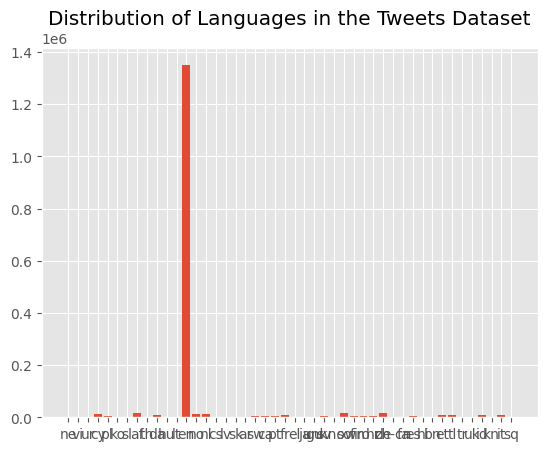

In [ ]:
df_timeline['language'] = languages
plt.bar(range(len(languages_dict)), list(languages_dict.values()), align='center')
plt.xticks(range(len(languages_dict)), list(languages_dict.keys()))
plt.title("Distribution of Languages in the Tweets Dataset")
plt.show()

In [ ]:
df_timeline[df_timeline['language'] == 'unknown'].text

,text
7202,New Emoji🤣🤡🤠🤤🤥🤐🤢🤧🕵🏻‍♀️🕵🏻👩🏼‍⚕️👨🏼‍⚕️👩🏼‍🌾👨🏼‍🌾👩🏻‍🍳...
20814,ｊｉｍｉｎ ｗｉｔｈ ｈｉｓｃｒｅｅｐｙｓｍｉｌｅ
21685,RT @ChristmasCount: 🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟\n🌟🎅🎅🎅🎅🌟🎅🎅🎅🎅🌟\n...
37465,GOSH😍😍😍😍😍😍😍😍😍 https://t.co/BhcMMO3xQg
40275,RT if u love\n❤❤❤❤\n❤\n❤ ❤❤\n❤ ❤\...
...,...
1497195,she lost😭😭😭😭😭😭😭😭😭😭😭😭😭😭😭😭😭😭😭😭😭😭😭😭😭😭😭😭😭😭😭😭😭😭😭😭😭 ...
1512966,THEYRE@COMIGNGNGNNF
1515299,*Worst behavior* 😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂...
1521431,Jonathan to Nigerians : 😛😛😛😛😝😝😝😝😝😝😝😝😝😝😝😝😝😝😝😝😝😝...


In [ ]:
df_timeline = df_timeline[df_timeline['language'] == 'en']

df_timeline['word_count'] = df_timeline['text'].apply(word_count)
df_timeline['word_count'].describe()

<ipython-input-15-5a9d551f7144>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_timeline['word_count'] = df_timeline['text'].apply(word_count)


,word_count
count,1.348915e+06
mean,1.328902e+01
std,6.678607e+00
min,1.000000e+00
25%,8.000000e+00
50%,1.200000e+01
75%,1.800000e+01
max,1.130000e+02


In [ ]:
WordCount_TargetClass (df_timeline, 'text', target='depression')

<ipython-input-7-e98451e0e2fb>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['word_count'] = data[column].apply(word_count)


In [ ]:
save_path = "/content/drive/MyDrive/MentalHealthProject/timeline_unstructured_data.csv"
df_timeline.to_csv(save_path, index=False)

# BERTweet Finetuning for Tweeter Data Classification
**Val accuracy 83.95%, Test accuracy 83.42%**

In [ ]:
save_path = "/content/drive/MyDrive/MentalHealthProject/timeline_unstructured_data.csv"
df_final = pd.read_csv(save_path)

In [ ]:
from sklearn import model_selection
from sklearn import metrics
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from transformers import AutoTokenizer
from transformers import AutoModel
from tqdm import tqdm
from re import sub
import torch.nn as nn
import torch
from sklearn.model_selection import train_test_split

In [ ]:
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 13.6 gigabytes of available RAM

Not using a high-RAM runtime


In [ ]:
df_final.rename(columns={"depression": "target"}, inplace=True)

In [ ]:
# Assuming df is your DataFrame and 'target' is your binary column
df, test_data = train_test_split(df_final, test_size=0.2, stratify=df_final['target'], random_state=42)

In [ ]:
# Checking class distribution
print(df['target'].value_counts(normalize=True))
print(test_data['target'].value_counts(normalize=True))

target
True     0.619696
False    0.380304
Name: proportion, dtype: float64
target
True     0.619696
False    0.380304
Name: proportion, dtype: float64


In [ ]:
# Find max and min word counts
max_words = df_final['word_count'].max()
min_words = df_final['word_count'].min()

max_words, min_words

(113, 1)

In [ ]:
class config:
    BERT_PATH = "vinai/bertweet-base"
    # this is the maximum number of tokens in the sentence
    MAX_LEN = 128
    # batch sizes is small because model is huge!
    TRAIN_BATCH_SIZE = 16
    VALID_BATCH_SIZE = 8
    EPOCHS = 5
    # this is where you want to save the model
    MODEL_PATH = '/content/drive/MyDrive/MentalHealthProject/model.bin'

In [ ]:
def sample(df):
    """
    return sample view of dataframe
    """
    sample_df = df.sample(1)
    for row , col in zip(sample_df.values[0], sample_df.columns):
        print(f'--{col}--\n\n{row}\n')

def clean_whitespace(text):
    """
    clean white space in text
    """
    if not text:
        return
    return " ".join(text.split())

def clean_data(text, add_keyword=None):
    """
    to clean tweets and keywords,
    solve formatting issue,
    remove hastags, usernames and links
    """
    # remove links
    text = sub(r'http\S+', '', text)
    # remove username
    text = sub(r'@\S+', '', text)
    text = text.replace('#', '')
    return clean_whitespace(text)

def get_data(df, test_data):
    """
    read and return data frame
    """
    df["contents"] = ''
    df["contents"] = df.text.apply(lambda x:clean_data(x))
    if test_data:
        return df
    df.rename(columns={'target': "targets"}, inplace=True)
    return df

In [ ]:
df = get_data(df, test_data=None)
test_data = get_data(test_data, test_data=True)

In [ ]:
TOKENIZER = AutoTokenizer.from_pretrained(config.BERT_PATH, do_lower_case=True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/843k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.91M [00:00<?, ?B/s]

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


In [ ]:
class DatasetTransformer:
    """
    :param content: list or numpy array of strings
    :param targets: list or numpy array which is binary
    """
    def __init__(self, contents, targets, test_data=None):
        self.contents = contents
        self.targets = targets
        self.tokenizer = TOKENIZER
        self.max_len = config.MAX_LEN
        self.test_data = test_data

    def __len__(self):
        return len(self.contents)

    def __getitem__(self, index):
        """
        for a given item index, return a dictionary
        of inputs.
        """
        content = str(self.contents[index])
        inputs = self.tokenizer.encode_plus(
            content,
            padding='max_length',
            max_length=self.max_len,
            truncation=True,
        )
        ids = inputs["input_ids"]
        mask = inputs["attention_mask"]
        token_type_ids = inputs["token_type_ids"]
        if self.test_data:
            return {
                "ids": torch.tensor(ids, dtype=torch.long),
                "mask": torch.tensor(mask, dtype=torch.long),
                "token_type_ids": torch.tensor(token_type_ids, dtype=torch.long)
            }
        target = self.targets[index]
        return {
            "ids": torch.tensor(ids, dtype=torch.long),
            "mask": torch.tensor(mask, dtype=torch.long),
            "token_type_ids": torch.tensor(token_type_ids, dtype=torch.long),
            "target": torch.tensor(target, dtype=torch.float),

        }

In [ ]:
# Example
DatasetTransformer(df.contents, df.targets)[0]

{'ids': tensor([  0,   8,  70, 143,  51, 141,  33,   2,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1]),
 'mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0

In [ ]:
class BERTweet(nn.Module):
    def __init__(self):
        super(BERTweet, self).__init__()
        self.bert = AutoModel.from_pretrained(config.BERT_PATH)
        # add a dropout for regularization
        self.bert_drop = nn.Dropout(0.3)
        # hidden size can be 768 or 1024 depending
        # on the transfomer model we are using
        # in our case, it is 768
        self.out = nn.Linear(768, 1)

    def forward(self, ids, mask, token_type_ids):
        """
        bert will return 2 dicts with keys
        'pooler_output' and 'last_hidden_state'
        we need pooler_output with size torch.Size([batch size, hidden_size])
        """
        bert_output = self.bert(
            ids,
            attention_mask=mask,
            token_type_ids=token_type_ids
        )
        reguralized_output = self.bert_drop(bert_output["pooler_output"])
        output = self.out(reguralized_output)
        return output

In [ ]:
def train_model(data_loader, model, optimizer, epoch, device, scheduler):
    """
    This is the main training function that trains model
    for one epoch
    :param data_loader: this is the torch dataloader
    :param model: transformer- model
    :param optimizer: torch optimizer, e.g. adam, sgd, etc.
    :param device: this can be "cuda" or "cpu"
    :param scheduler: learning rate scheduler
    """
    # set model to training mode
    model.train()
    # go through batches of data in data loader
    print(f'training for epoch {epoch}')
    for data in tqdm(data_loader):
        # extract ids, token type ids and mask
        # from current batch
        # also extract targets
        ids = data["ids"]
        token_type_ids = data["token_type_ids"]
        mask = data["mask"]
        targets = data["target"]
        # move everything to specified device
        ids = ids.to(device, dtype=torch.long)
        token_type_ids = token_type_ids.to(device, dtype=torch.long)
        mask = mask.to(device, dtype=torch.long)
        targets = targets.to(device, dtype=torch.float)
        optimizer.zero_grad()
        # pass through the model
        predictions = model(
            ids=ids,
            mask=mask,
            token_type_ids=token_type_ids
        )
        # calculate the loss
        loss = nn.BCEWithLogitsLoss()(
            predictions,
            targets.view(-1, 1)
        )
        # compute gradient of loss w.r.t.
        # all parameters of the model that are trainable
        loss.backward()
        # single optimization step
        optimizer.step()
        # step scheduler
        scheduler.step()
    print(f'training loss for epoch {epoch} {loss}')


def evaluate(data_loader, model, device):
    """
    validation loop
    """
    # initialize empty lists to store predictions
    # and targets
    final_predictions = []
    final_targets = []
    # put the model in eval mode
    model.eval()
    # disable gradient calculation
    with torch.no_grad():
        for data in data_loader:
            ids = data["ids"]
            token_type_ids = data["token_type_ids"]
            mask = data["mask"]
            targets = data["target"]
            ids = ids.to(device, dtype=torch.long)
            token_type_ids = token_type_ids.to(device, dtype=torch.long)
            mask = mask.to(device, dtype=torch.long)
            targets = targets.to(device, dtype=torch.float)
            # make predictions
            outputs = model(
                ids=ids,
                mask=mask,
                token_type_ids=token_type_ids
            )
            # move predictions and targets to list
            # we need to move predictions and targets to cpu too
            targets = targets.cpu().detach()
            targets = targets.numpy().tolist()
            final_targets.extend(targets)
            # convert outputs to cpu and extend the final list
            outputs = torch.sigmoid(outputs).cpu().detach()
            outputs = outputs.numpy().tolist()
            final_predictions.extend(outputs)
    return final_predictions, final_targets

In [ ]:
def get_optimizer_param(model):
    """
    return optimizer paramters after applying
    weight decay to all parameters other
    than bias and layer normalization terms:
    """
    param_optimizer = list(model.named_parameters())
    no_decay = ["bias", "LayerNorm.weight"]
    optimizer_parameters = [
        {
            "params": [
                p for n, p in param_optimizer if not any(nd in n for nd in no_decay) # noqa
                ],
            "weight_decay": 0.001,
        },
        {
            "params": [
                p for n, p in param_optimizer if any(nd in n for nd in no_decay)], # noqa
            "weight_decay": 0.0,
        },
    ]
    return optimizer_parameters


def get_scheduler(optimizer, num_train_steps):
    """
    return learning rate scheduler based on the
    optimizer and training steps.

    """
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=num_train_steps
    )
    return scheduler

In [ ]:
def run(data_df):
    df_train, df_valid = model_selection.train_test_split(
        data_df,
        test_size=0.1,
        random_state=42,
    )
    # reset index
    df_train = df_train.reset_index(drop=True)
    df_valid = df_valid.reset_index(drop=True)
    # Initialize training and validation dataset
    train_dataset = DatasetTransformer(
        df_train.contents.values,
        df_train.targets.values
    )
    valid_dataset = DatasetTransformer(
        df_valid.contents.values,
        df_valid.targets.values
    )
    # create training and validation dataloader
    train_data_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=config.TRAIN_BATCH_SIZE,
        num_workers=1
    )
    valid_data_loader = torch.utils.data.DataLoader(
        valid_dataset,
        batch_size=config.VALID_BATCH_SIZE,
        num_workers=1
    )
    availble_device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f'Training in device {availble_device}')
    device = torch.device(availble_device)
    model = BERTweet()
    # send model to device
    model.to(device)
    optimizer_parameters = get_optimizer_param(model)
    optimizer = AdamW(optimizer_parameters, lr=3e-5)
    num_train_steps = int(
        len(df_train) / config.TRAIN_BATCH_SIZE * config.EPOCHS
    )
    scheduler = get_scheduler(optimizer, num_train_steps)
    best_accuracy = 0
    print(f'Total no of epochs = {config.EPOCHS}')
    for epoch in range(config.EPOCHS):
        # train one epoch
        train_model(
            train_data_loader, model, optimizer, epoch,
            device, scheduler
        )
        # validate
        outputs, targets = evaluate(
            valid_data_loader,
            model,
            device
        )
        outputs = np.array(outputs) >= 0.5
        accuracy = metrics.accuracy_score(targets, outputs)
        print(
            f"\n epoch:{epoch} | Validation Accuracy Score = {accuracy}."
        )
        if accuracy > best_accuracy:
            torch.save(model.state_dict(), config.MODEL_PATH)
            best_accuracy = accuracy

In [ ]:
run(df)

Training in device cuda
Total no of epochs = 5
training for epoch 0


100%|██████████| 31395/31395 [2:56:36<00:00,  2.96it/s]


training loss for epoch 0 0.25703391432762146

 epoch:0 | Validation Accuracy Score = 0.8192177449698099.
training for epoch 1


100%|██████████| 31395/31395 [2:56:48<00:00,  2.96it/s]


training loss for epoch 1 0.21652966737747192

 epoch:1 | Validation Accuracy Score = 0.8319746295665884.
training for epoch 2


...

training loss for epoch 2 0.1797247678041458

 epoch:2 | Validation Accuracy Score = 0.8367226273448838.
training for epoch 3


100%|██████████| 31395/31395 [2:56:36<00:00,  2.96it/s]


training loss for epoch 3 0.07712981849908829

 epoch:3 | Validation Accuracy Score = 0.8370451328543529.
training for epoch 4


100%|██████████| 31395/31395 [2:56:37<00:00,  2.96it/s]


training loss for epoch 4 0.043563954532146454

 epoch:4 | Validation Accuracy Score = 0.8394818411481196.


In [ ]:
# Running on A100 GPU
run(df)

Training in device cuda
Total no of epochs = 5
training for epoch 0


100%|██████████| 62790/62790 [50:54<00:00, 20.55it/s]

training loss for epoch 0 0.6600818634033203



 epoch:0 | Validation Accuracy Score = 0.6199093401178937.
training for epoch 1


100%|██████████| 62790/62790 [50:56<00:00, 20.55it/s]

...

training loss for epoch 3 0.6913415789604187



 epoch:3 | Validation Accuracy Score = 0.6199093401178937.
training for epoch 4


100%|██████████| 62790/62790 [50:59<00:00, 20.52it/s]

training loss for epoch 4 0.6862208247184753



 epoch:4 | Validation Accuracy Score = 0.6199093401178937.


In [ ]:
model = BERTweet()

In [ ]:
model.load_state_dict(torch.load(config.MODEL_PATH))

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

<All keys matched successfully>

In [ ]:
def inference(model, test_data):
    """
    to make predictions or inference
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    test_dataset = DatasetTransformer(
        test_data.contents.values, None, test_data=True)
    data_loader = torch.utils.data.DataLoader(
        test_dataset,
        batch_size=1,
        num_workers=1)
    final_predictions = []
    # put the model in eval mode
    model.eval()
    # disable gradient calculation
    with torch.no_grad():
        for data in tqdm(data_loader):
            ids = data["ids"]
            token_type_ids = data["token_type_ids"]
            mask = data["mask"]
            ids = ids.to(device, dtype=torch.long)
            token_type_ids = token_type_ids.to(device, dtype=torch.long)
            mask = mask.to(device, dtype=torch.long)
            # make predictions
            outputs = model(
                ids=ids,
                mask=mask,
                token_type_ids=token_type_ids
            )
            outputs = torch.sigmoid(outputs).cpu().detach()
            outputs = outputs.numpy().tolist()
            final_predictions.extend(outputs)
    return final_predictions

In [ ]:
predictions = inference(model, test_data)

100%|██████████| 139533/139533 [27:56<00:00, 83.23it/s]


In [ ]:
predictions = np.array(predictions) >= 0.5
predictions = predictions.flatten()
predictions_df = pd.DataFrame(predictions, columns=['target'])

In [ ]:
metrics.accuracy_score(
    predictions_df.target.values,
    test_data.target.values
)

0.834204095088617